### Imports and definitions

In [1]:
import h5py as h5 
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tol_colors as tc

import useful_fncs
import utils_from_others
import figure_utils

# plotting imports
# import for axes labels 
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### Read in Data

Similarly to the formation efficiencies and delay times our systems of interest are those that merge in a Hubble Time and are 
1) two neutron stars (NSNS)
2) a carbon oyxygen white dwarf and any white dwarf (COWD+WD)

We will use the DCOmask filter to help us select for these systems, and then booleans to make further selections.
We will use the NSNS optimized run to analyze the delay time distribution for the NSNS systems, and the WDWD optimized run to look at the delay time distribution for the COWD+WD systems.

In [2]:
## NSNS optimized run

# let's first look at the NSNS_output
pathToH5_NSNS = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_NSNS  = h5.File(pathToH5_NSNS, "r")

DCOs_NSNS = Data_NSNS['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

In [3]:
# gathering information to mask the data even more
# merges in a Hubble Time
Merges_Hubble_Time = Data_NSNS['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
Merges_Hubble_Time_DCO = Merges_Hubble_Time[DCO_mask_NSNS]
condition_mergers = Merges_Hubble_Time_DCO == True

# gathering the rates data
rates_DCO = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked = rates_DCO[condition_mergers]

In [4]:
redshifts_NSNS = Data_NSNS['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

In [6]:
# gathering just the DCO objects that merge within a Hubble Time
stellar_types_all_1 = DCOs_NSNS['Stellar_Type(1)'][()]
stellar_types_1_DCO = stellar_types_all_1[DCO_mask_NSNS]
stellar_types_1_merged = stellar_types_1_DCO[condition_mergers]

stellar_types_all_2 = DCOs_NSNS['Stellar_Type(2)'][()]
stellar_types_2_DCO = stellar_types_all_2[DCO_mask_NSNS]
stellar_types_2_merged = stellar_types_2_DCO[condition_mergers]

# bool for just the NSNS systems
NSNS_systems_bool = np.logical_and(stellar_types_1_merged==13, stellar_types_2_merged==13)

# gathering the mixture weight info
mixture_weights_all = DCOs_NSNS['mixture_weight'][()]
mixtrue_weights_merged = mixture_weights_all[DCO_mask_NSNS]
mixture_weights_merged_NSNS = mixtrue_weights_merged[NSNS_systems_bool*condition_mergers]

#### Let's do the same for the WDWD systems

In [2]:
## WDWD optimized run
pathToH5_WDWD = '/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_MassiveWDWD_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5'

Data_WDWD  = h5.File(pathToH5_WDWD, "r")

DCOs_WDWD = Data_WDWD['BSE_Double_Compact_Objects'] # getting the DCO objects

# gathering the double compact objects that we have computed rates for
DCO_mask_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

DATA_SPS_WDWD = Data_WDWD['BSE_System_Parameters']

In [3]:
# gathering information to mask the data even more
# merges in a Hubble Time
Merges_Hubble_Time_WDopt = Data_WDWD['BSE_Double_Compact_Objects']['Merges_Hubble_Time'][()]
Merges_Hubble_Time_DCO_WDopt = Merges_Hubble_Time_WDopt[DCO_mask_WDWD]
condition_mergers_WDopt = Merges_Hubble_Time_DCO_WDopt == True

# gathering the rates data
rates_DCO_WDopt = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate'][()]
rates_DCO_masked_WDopt = rates_DCO_WDopt[condition_mergers_WDopt]

In [4]:
redshifts_WDWD = Data_WDWD['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['redshifts'][()]

In [5]:
stellar_types_all_1_WDopt = DCOs_WDWD['Stellar_Type(1)'][()]
stellar_types_1_DCO_WDopt = stellar_types_all_1_WDopt[DCO_mask_WDWD]
stellar_types_1_merged_WDopt = stellar_types_1_DCO_WDopt[condition_mergers_WDopt]

stellar_types_all_2 = DCOs_WDWD['Stellar_Type(2)'][()]
stellar_types_2_DCO = stellar_types_all_2[DCO_mask_WDWD]
stellar_types_2_merged_WDopt = stellar_types_2_DCO[condition_mergers_WDopt]

# gathering the masses
mass_1_all = DCOs_WDWD['Mass(1)'][()]
mass_1_DCO = mass_1_all[DCO_mask_WDWD]
mass_1_merged = mass_1_DCO[condition_mergers_WDopt]

mass_2_all = DCOs_WDWD['Mass(2)'][()]
mass_2_DCO = mass_2_all[DCO_mask_WDWD]
mass_2_merged = mass_2_DCO[condition_mergers_WDopt]

# we are going to conditions that M1>M2 (not considering mass ratio reversal cases)
M1 = np.maximum(mass_1_merged, mass_2_merged)
M2 = np.minimum(mass_1_merged, mass_2_merged)

# gathering the mixture weight info
mixture_weights_all_WDopt = DCOs_WDWD['mixture_weight'][()]
mixtrue_weights_dco_WDopt = mixture_weights_all_WDopt[DCO_mask_WDWD]
mixtrue_weights_merged_WDopt = mixtrue_weights_dco_WDopt[condition_mergers_WDopt]

In [6]:
# let's find the bools for each of our progenitor systems

# WDWD bool with at least one COWD + COWD/HeWD
HeWD_bool_WDWD,COWD_bool_WDWD,ONeWD_bool_WDWD,HeCOWD_bool_WDWD,HeONeWD_bool_WDWD,COHeWD_bool_WDWD,COONeWD_bool_WDWD,ONeHeWD_bool_WDWD,ONeCOWD_bool_WDWD = useful_fncs.WD_BINARY_BOOLS(stellar_types_1_merged_WDopt, stellar_types_2_merged_WDopt)
carbon_oxygen_bool_WDWD_merged_WDopt = np.logical_or(COHeWD_bool_WDWD, np.logical_or(COWD_bool_WDWD, HeCOWD_bool_WDWD))

# violent merger - unequal mass + COWD+COWD
mass_unequal_conditon = mass_1_merged >= 1.0
violent_merger_unequal_bool = mass_unequal_conditon*COWD_bool_WDWD

# violent merger - equal mass (q_cr = 0.9) + COWD+COWD
mass_min_criteria = np.logical_and(mass_1_merged>=0.8, mass_2_merged>=0.8)
critical_mass_ratio_bool = np.logical_and(M2/M1 >= 0.9, mass_min_criteria)
violent_merger_equal_bool = critical_mass_ratio_bool*COWD_bool_WDWD

# D6 HVS
SN_Ia_HVS,two_star_SNIA,Champagne_Supernova = useful_fncs.check_if_SNIA(mass_1_merged, mass_2_merged)

# D6 - two explosion
mass_D6_condition = mass_1_merged < 1.0
d6_two_explosion = mass_D6_condition*carbon_oxygen_bool_WDWD_merged_WDopt

### Let's compute the merger rate

In [7]:
# NSNS_rate = np.sum(rates_DCO_masked[NSNS_systems_bool], axis=0)

In [8]:
cowd_rate = np.sum(rates_DCO_masked_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt], axis=0)

In [9]:
violent_merger_unequal_rate = np.sum(rates_DCO_masked_WDopt[violent_merger_unequal_bool], axis=0)

In [10]:
violent_merger_equal_rate = np.sum(rates_DCO_masked_WDopt[violent_merger_equal_bool], axis=0)

In [11]:
HVS_rate = np.sum(rates_DCO_masked_WDopt[SN_Ia_HVS], axis=0)

In [12]:
D6_two_explosion_rate = np.sum(rates_DCO_masked_WDopt[d6_two_explosion], axis=0)

Let's bootstrap these rates!

In [12]:
# let's now do boostrapping for each run

NSNS_rate_2D = rates_DCO_masked[NSNS_systems_bool] # NSNS optimized
percentiles = useful_fncs.bootstrapping_intervals(NSNS_rate_2D, 50, redshifts_NSNS)

Bootstrapping :[############################################################] 50/50


In [13]:
WDWD_rate_2D = rates_DCO_masked_WDopt[carbon_oxygen_bool_WDWD_merged_WDopt] # WDWD optimized
percentiles_WDWD = useful_fncs.bootstrapping_intervals(WDWD_rate_2D, 50, redshifts_WDWD)

Bootstrapping :[############################################################] 50/50


### Plotting!

In [14]:
h_little = 0.6766

redshifts_briel = [
    0, 0.01, 0.03, (0.025+0.050)/2, 0.073, (0.05+0.15)/2, (0.075+0.125)/2, 0.11, 0.11, 0.13, 
    0.15, (0.125+0.175)/2, 0.16, (0.175+0.225)/2, 0.2, 0.25, (0.15+0.35)/2, (0.225+0.275)/2, 
    0.26, 0.3, (0.275+0.325)/2, 0.35, 0.35, 0.42, 0.44, 0.45, 0.45, (0.35+0.55)/2, 0.46, 0.47, 
    0.47, 0.55, 0.55, 0.55, 0.62, 0.65, (0.55+0.75)/2, 0.65, 0.74, 0.75, 0.75, 0.75, 0.8, 0.83, 0.85, 
    0.85, 0.94, 0.95, 0.95, 1.05, 1.1, 1.14, 1.21, 1.23, 1.25, 1.59, 1.61, 1.69, 1.75, 2.25
]

rates_briel = [
    0.77, 0.82, 0.82, 0.81, 0.71, 1.60, 0.76, 1.08, 0.72, 0.58, 0.93, 0.90, 0.41, 1.01, 0.58,
    1.05, 1.14, 1.06, 0.82, 0.99, 1.27, 0.99, 1.05, 1.34, 0.76, 0.90, 1.05, 1.52, 1.40, 1.22, 
    2.33, 0.93, 1.40, 1.52, 3.76, 1.40, 2.01, 1.43, 2.30, 1.49, 1.98, 1.69, 2.45, 3.79, 2.27, 
    1.66, 1.31, 2.22, 2.24, 2.30, 2.16, 2.06, 3.85, 2.45, 1.87, 1.31, 1.22, 2.97, 2.10, 1.43
]

# converting the rates to the correct units
rates_briel = np.array(rates_briel)
converted_rates_briel = (rates_briel*(10**5))*(h_little**3)

## uncertainties
lower_limits = [
    -0.10, -0.26, -0.32, -0.24, -0.08, -0.85, -0.13, -0.29, -0.20, -0.18, -0.67, -0.10, -0.26, -0.09, 
    -0.23, -0.76, -0.35, -0.08, -0.20, -0.44, -0.10, -0.55, -0.17, -0.93, -0.39, -0.44, -0.17, -0.38, 
    -0.50, -0.17, -0.79, -0.41, -0.17, -0.26, -1.66, -0.15, -0.52, -0.50, -1.20, -0.55, -0.61, -0.17, 
    -0.54, -0.79, -0.64, -0.15, -0.55, -0.73, -0.23, -0.82, -0.35, -0.53, -0.85, -0.82, -0.64, -0.64, 
    -0.67, -1.08, -0.87, -1.11
]

lower_limits = np.array(lower_limits)
converted_lower_limits = (lower_limits*(10**5)*(h_little**3))

upper_limits = [
    0.10, 0.26, 0.32, 0.33, 0.08, 1.46, 0.15, 0.29, 0.08, 0.20, 0.67, 0.11, 0.26, 0.09, 0.23,
    1.75, 0.38, 0.09, 0.20, 0.47, 0.11, 0.55, 0.17, 1.22, 0.67, 0.44, 0.17, 0.32, 0.50, 0.17, 
    1.08, 0.41, 0.17, 0.29, 2.57, 0.15, 0.55, 0.50, 0.96, 0.79, 0.61, 0.17, 0.67, 0.96, 0.64, 
    0.15, 0.64, 0.73, 0.23, 0.82, 0.35, 0.70, 1.05, 0.73, 0.90, 0.99, 1.14, 1.57, 1.31, 2.77
]

upper_limits = np.array(upper_limits)
converted_upper_limits = (upper_limits*(10**5)*(h_little**3))

# multiplied the lower errors by -1 so make them positive to avoid the plt.errorbar error 
y_error = [-1*(converted_lower_limits), converted_upper_limits]


NameError: name 'redshifts_NSNS' is not defined

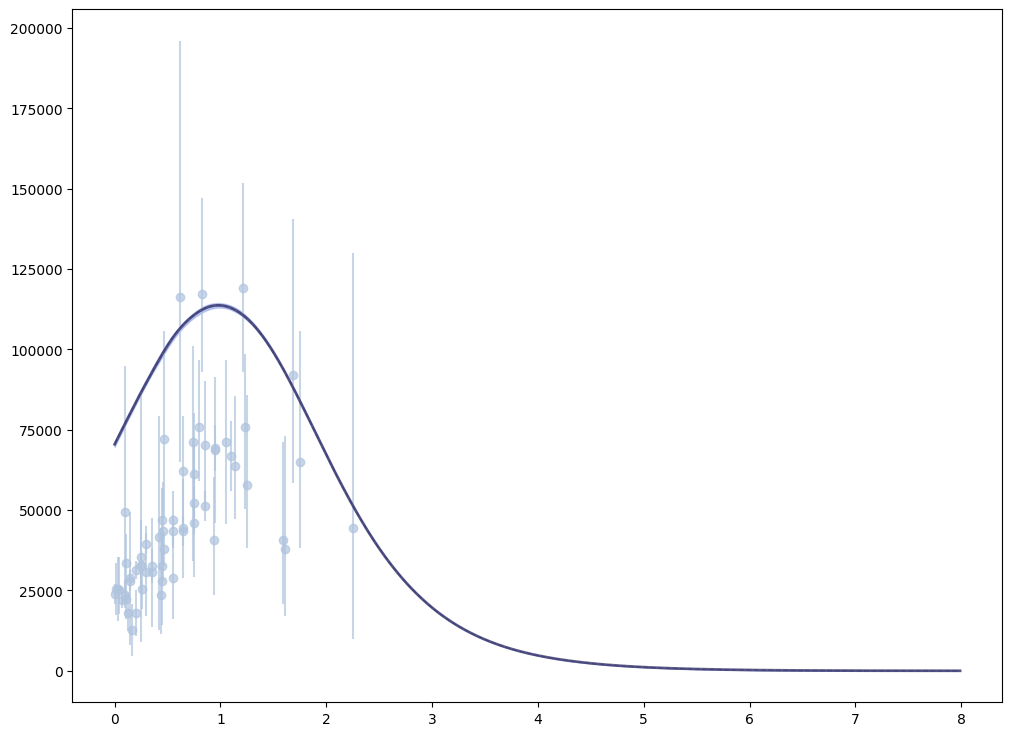

In [16]:
# plotting formation efficencies

fig, ax = plt.subplots(figsize = (12, 9))
cset = tc.dark
cset_l = tc.light

# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax.errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'lightsteelblue', alpha=0.7)#,label='Briel et al. 2023')

# COWD
ax.fill_between(redshifts_WDWD, percentiles_WDWD[0], percentiles_WDWD[2], alpha = 0.3, color = 'royalblue')
ax.plot(redshifts_WDWD, percentiles_WDWD[1],linewidth=1,color='mediumpurple', ls="--", alpha=0.7)#,label='WDWD rate bootstrapped median')
ax.plot(redshifts_WDWD, cowd_rate, linewidth=2,color=cset.dark_blue,alpha=0.7,label='WDWD rate merged')

# NSNS
ax.fill_between(redshifts_NSNS, percentiles[0], percentiles[2], alpha = 0.3, color = 'forestgreen')
ax.plot(redshifts_NSNS, percentiles[1],linewidth=2,color='green', ls="--", alpha=0.7)#,label='NSNS rate bootstrapped median')
ax.plot(redshifts_NSNS, NSNS_rate,linewidth=2, color=cset.dark_green,alpha=0.7,label='NSNS rate merged')
# some outlier that may give you high rate but when we bootstrapp we could remove the outliers and the rate can be very different 


ax.set_yscale('log')
ax.set_ylabel(r"$\mathcal{R}$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=20)
ax.set_xlabel(r"Redshift",fontsize=25)
ax.tick_params(axis='x', length=8, width=1, labelsize=15)
ax.tick_params(axis='y', length=8, width=1, labelsize=12)
ax.legend(fontsize=15)

Text(0.5, 1.0, 'Rates vs Redshift')

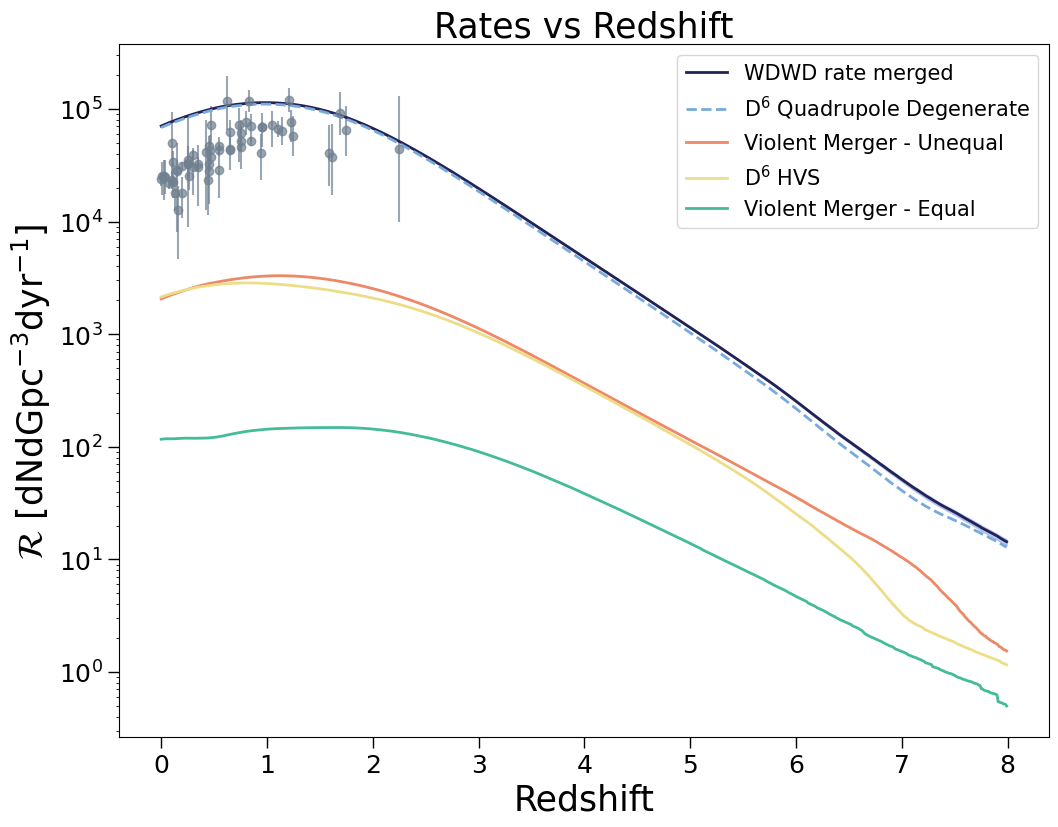

In [27]:
# let's make the plot with just the WDWD progenitor systems

# plotting formation efficencies

fig, ax = plt.subplots(figsize = (12, 9))
cset = tc.dark

# observational constraints from Briel et al. 2023 Table A1 - https://academic.oup.com/mnras/article/514/1/1315/6576337
ax.errorbar(redshifts_briel,converted_rates_briel,yerr=y_error, fmt='o', color = 'slategrey', alpha=0.7)#,label='Briel et al. 2023')

# COWD
ax.fill_between(redshifts_WDWD, percentiles_WDWD[0], percentiles_WDWD[2], alpha = 0.3, color = 'royalblue')
ax.plot(redshifts_WDWD, percentiles_WDWD[1],linewidth=1,color='mediumpurple', ls="--", alpha=0.7)#,label='WDWD rate bootstrapped median')
ax.plot(redshifts_WDWD, cowd_rate, linewidth=2,color=cset.dark_blue,label='COWD+WD merged')

# D^6 two explosion 
ax.plot(redshifts_WDWD, D6_two_explosion_rate, linewidth=2,color=cset_l.light_blue, ls="--",label='$\mathrm{D^6}$ Quadrupole Degenerate')

# violent merger - unequal 
ax.plot(redshifts_WDWD, violent_merger_unequal_rate, linewidth=2,color=cset_l.orange,label='Violent Merger - Unequal')

# HVS
ax.plot(redshifts_WDWD, HVS_rate, linewidth=2,color=cset_l.light_yellow,label='$\mathrm{D^6}$ HVS')

# violent merger - equal
ax.plot(redshifts_WDWD, violent_merger_equal_rate, linewidth=2,color=cset_l.mint,label='Violent Merger - Equal')




ax.set_yscale('log')
ax.set_ylabel(r"$\mathcal{R}$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=25)
ax.set_xlabel(r"Redshift",fontsize=25)
ax.tick_params(axis='x', length=8, width=1, labelsize=18)
ax.tick_params(axis='y', length=8, width=1, labelsize=18)
ax.legend(fontsize=15)
ax.set_title("Rates vs Redshift", fontsize=25)

## save figure:
# plt.savefig("../figures/rates_redshift.png",bbox_inches='tight',pad_inches=0.1)

### Close the data file

In [78]:
Data_NSNS.close()
Data_WDWD.close()